In [1]:
import os
import sys
import subprocess
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

Python: 3.11.4 (main, Nov  4 2023, 03:43:13) [GCC 12.3.1 20230526]
PyTorch: 2.7.1
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB MIG 3g.20gb
CUDA version: 12.6


In [2]:
# --- the ONE line that decides scratch vs paper-recipe ---
IMAGENET_PRETRAINED = "/home/dpraju90/scratch/PIDNet_S_ImageNet.pth.tar"   # paper recipe
# IMAGENET_PRETRAINED = None                                               # true from-scratch (random init)

RESUME     = True    # fresh run from epoch 0 (ignores old random-init checkpoints)
SMOKE_TEST = False    # real run, not the 3-epoch dry run
WORKERS    = 0        # kills the DataLoader traceback flood on 1 CPU
END_EPOCH  = 484      # keep the denominator fixed; resume across sessions later

In [3]:
for split in ["train", "val", "test"]:
    image_dir = IMAGE_ROOT / split
    label_dir = LABEL_ROOT / split

    print(
        split,
        "| images:", image_dir.exists(),
        "| labels:", label_dir.exists()
    )

NameError: name 'IMAGE_ROOT' is not defined

In [4]:
def count_files(root, pattern):
    return len(list(root.rglob(pattern)))

train_images = count_files(IMAGE_ROOT / "train", "*_leftImg8bit.png")
val_images = count_files(IMAGE_ROOT / "val", "*_leftImg8bit.png")
test_images = count_files(IMAGE_ROOT / "test", "*_leftImg8bit.png")

train_labels = count_files(
    LABEL_ROOT / "train",
    "*_gtFine_labelIds.png"
)

val_labels = count_files(
    LABEL_ROOT / "val",
    "*_gtFine_labelIds.png"
)

print("Train images :", train_images)
print("Val images   :", val_images)
print("Test images  :", test_images)
print("Train labels :", train_labels)
print("Val labels   :", val_labels)

NameError: name 'IMAGE_ROOT' is not defined

In [3]:
import os

REPO_DIR = "/home/dpraju90/scratch/PIDNet"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/XuJiacong/PIDNet.git {REPO_DIR}
else:
    print("PIDNet already cloned.")

PIDNet already cloned.


In [4]:
# =============================================================================
# 0. Config  ·  EDIT THIS CELL ONLY
# =============================================================================
import os

# --- your data on scratch (already extracted) ---
IMAGES_DIR = "/home/dpraju90/scratch/leftImg8bit_trainvaltest/leftImg8bit"  # has train/ val/ test/
LABELS_DIR = "/home/dpraju90/scratch/gtFine_trainvaltest/gtFine"            # has train/ val/ test/

# --- where checkpoints/outputs go (keep on scratch, not $HOME) ---
OUT_DIR = os.path.expanduser("~/scratch/pidnet_runs")
os.makedirs(OUT_DIR, exist_ok=True)

# --- model size: "s" (32ch), "m" (64ch), "l" (64ch, deeper) ---
MODEL_SIZE = "s"

# --- training knobs ---
NUM_CLASSES   = 19
IGNORE_LABEL  = 255
BATCH_SIZE    = 6            # per GPU. lower to 4/3/2 if you hit OOM at 1024 crop
VAL_BATCH     = 2            # val runs at full 1024x2048, keep small
WORKERS       = 6            # match --cpus-per-task
CROP_SIZE     = (1024, 1024) # (h, w) training crop
BASE_SIZE     = 2048
SCALE_FACTOR  = 16
END_EPOCH     = 150          # paper schedule (from scratch needs the long run)
BASE_LR       = 0.01
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4
VAL_EVERY     = 5            # validate every N epochs (then every epoch in last 100)
SEED          = 304

# --- from-scratch: no ImageNet init (random weights) ---
IMAGENET_PRETRAINED = None   # leave None to train from scratch

# --- resume from last checkpoint if the job timed out ---
RESUME = True

# --- quick end-to-end smoke test first (tiny run). Set False for the real run. ---
SMOKE_TEST = False
if SMOKE_TEST:
    END_EPOCH = 3
    VAL_EVERY = 1

RUN_DIR = os.path.join(OUT_DIR, f"pidnet_{MODEL_SIZE}_cityscapes")
os.makedirs(RUN_DIR, exist_ok=True)
print("model:", MODEL_SIZE, "| epochs:", END_EPOCH, "| batch:", BATCH_SIZE,
      "| from scratch:", IMAGENET_PRETRAINED is None)
print("checkpoints ->", RUN_DIR)

model: s | epochs: 150 | batch: 6 | from scratch: True
checkpoints -> /home/dpraju90/scratch/pidnet_runs/pidnet_s_cityscapes


In [5]:
# =============================================================================
# 1. Build train/val file lists straight from your scratch folders (no repo)
# =============================================================================
# Cityscapes layout is deterministic:
#   leftImg8bit/<split>/<city>/<name>_leftImg8bit.png
#   gtFine/<split>/<city>/<name>_gtFine_labelIds.png
import glob, os

def build_pairs(split):
    imgs = sorted(glob.glob(os.path.join(IMAGES_DIR, split, "*", "*_leftImg8bit.png")))
    pairs = []
    missing = 0
    for ip in imgs:
        name = os.path.basename(ip).replace("_leftImg8bit.png", "")
        city = os.path.basename(os.path.dirname(ip))
        lp = os.path.join(LABELS_DIR, split, city, name + "_gtFine_labelIds.png")
        if os.path.isfile(lp):
            pairs.append((ip, lp))
        else:
            missing += 1
    return pairs, missing

train_pairs, m1 = build_pairs("train")
val_pairs,   m2 = build_pairs("val")
assert len(train_pairs) > 0, f"No training images found under {IMAGES_DIR}/train"
print(f"train: {len(train_pairs)} pairs ({m1} imgs w/o label)")
print(f"val  : {len(val_pairs)} pairs ({m2} imgs w/o label)")
print("example:", os.path.relpath(train_pairs[0][0], IMAGES_DIR), "|",
      os.path.relpath(train_pairs[0][1], LABELS_DIR))

train: 2975 pairs (0 imgs w/o label)
val  : 500 pairs (0 imgs w/o label)
example: train/aachen/aachen_000000_000019_leftImg8bit.png | train/aachen/aachen_000000_000019_gtFine_labelIds.png


In [6]:
# =============================================================================
# 2. Model building blocks  (BasicBlock, Bottleneck, heads, PAPPM/DAPPM,
#    PagFM, Bag, Light_Bag) — faithful to the official PIDNet implementation
# =============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

bn_mom = 0.1
algc = False  # align_corners for the model's internal interpolations

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None, no_relu=False):
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes, momentum=bn_mom)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, momentum=bn_mom)
        self.downsample = downsample
        self.no_relu = no_relu
    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        return out if self.no_relu else self.relu(out)

class Bottleneck(nn.Module):
    expansion = 2
    def __init__(self, inplanes, planes, stride=1, downsample=None, no_relu=True):
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes, momentum=bn_mom)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, momentum=bn_mom)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion, momentum=bn_mom)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.no_relu = no_relu
    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        return out if self.no_relu else self.relu(out)

class segmenthead(nn.Module):
    def __init__(self, inplanes, interplanes, outplanes, scale_factor=None):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, momentum=bn_mom)
        self.conv1 = nn.Conv2d(inplanes, interplanes, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(interplanes, momentum=bn_mom)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(interplanes, outplanes, 1, padding=0, bias=True)
        self.scale_factor = scale_factor
    def forward(self, x):
        x = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(x)))
        if self.scale_factor is not None:
            h, w = x.shape[-2] * self.scale_factor, x.shape[-1] * self.scale_factor
            out = F.interpolate(out, size=[h, w], mode='bilinear', align_corners=algc)
        return out

class DAPPM(nn.Module):
    def __init__(self, inplanes, branch_planes, outplanes, BN=nn.BatchNorm2d):
        super().__init__()
        def pool(k, s, p):
            return nn.Sequential(nn.AvgPool2d(k, s, p), BN(inplanes, momentum=bn_mom),
                                 nn.ReLU(inplace=True), nn.Conv2d(inplanes, branch_planes, 1, bias=False))
        self.scale1, self.scale2, self.scale3 = pool(5,2,2), pool(9,4,4), pool(17,8,8)
        self.scale4 = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), BN(inplanes, momentum=bn_mom),
                                    nn.ReLU(inplace=True), nn.Conv2d(inplanes, branch_planes, 1, bias=False))
        self.scale0 = nn.Sequential(BN(inplanes, momentum=bn_mom), nn.ReLU(inplace=True),
                                    nn.Conv2d(inplanes, branch_planes, 1, bias=False))
        def proc():
            return nn.Sequential(BN(branch_planes, momentum=bn_mom), nn.ReLU(inplace=True),
                                 nn.Conv2d(branch_planes, branch_planes, 3, padding=1, bias=False))
        self.process1, self.process2, self.process3, self.process4 = proc(), proc(), proc(), proc()
        self.compression = nn.Sequential(BN(branch_planes*5, momentum=bn_mom), nn.ReLU(inplace=True),
                                         nn.Conv2d(branch_planes*5, outplanes, 1, bias=False))
        self.shortcut = nn.Sequential(BN(inplanes, momentum=bn_mom), nn.ReLU(inplace=True),
                                      nn.Conv2d(inplanes, outplanes, 1, bias=False))
    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        up = lambda t: F.interpolate(t, size=[h,w], mode='bilinear', align_corners=algc)
        xl = [self.scale0(x)]
        xl.append(self.process1(up(self.scale1(x)) + xl[0]))
        xl.append(self.process2(up(self.scale2(x)) + xl[1]))
        xl.append(self.process3(up(self.scale3(x)) + xl[2]))
        xl.append(self.process4(up(self.scale4(x)) + xl[3]))
        return self.compression(torch.cat(xl, 1)) + self.shortcut(x)

class PAPPM(nn.Module):
    def __init__(self, inplanes, branch_planes, outplanes, BN=nn.BatchNorm2d):
        super().__init__()
        def pool(k, s, p):
            return nn.Sequential(nn.AvgPool2d(k, s, p), BN(inplanes, momentum=bn_mom),
                                 nn.ReLU(inplace=True), nn.Conv2d(inplanes, branch_planes, 1, bias=False))
        self.scale1, self.scale2, self.scale3 = pool(5,2,2), pool(9,4,4), pool(17,8,8)
        self.scale4 = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), BN(inplanes, momentum=bn_mom),
                                    nn.ReLU(inplace=True), nn.Conv2d(inplanes, branch_planes, 1, bias=False))
        self.scale0 = nn.Sequential(BN(inplanes, momentum=bn_mom), nn.ReLU(inplace=True),
                                    nn.Conv2d(inplanes, branch_planes, 1, bias=False))
        self.scale_process = nn.Sequential(BN(branch_planes*4, momentum=bn_mom), nn.ReLU(inplace=True),
                                nn.Conv2d(branch_planes*4, branch_planes*4, 3, padding=1, groups=4, bias=False))
        self.compression = nn.Sequential(BN(branch_planes*5, momentum=bn_mom), nn.ReLU(inplace=True),
                                          nn.Conv2d(branch_planes*5, outplanes, 1, bias=False))
        self.shortcut = nn.Sequential(BN(inplanes, momentum=bn_mom), nn.ReLU(inplace=True),
                                      nn.Conv2d(inplanes, outplanes, 1, bias=False))
    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        up = lambda t: F.interpolate(t, size=[h,w], mode='bilinear', align_corners=algc)
        x_ = self.scale0(x)
        sl = [up(self.scale1(x))+x_, up(self.scale2(x))+x_, up(self.scale3(x))+x_, up(self.scale4(x))+x_]
        scale_out = self.scale_process(torch.cat(sl, 1))
        return self.compression(torch.cat([x_, scale_out], 1)) + self.shortcut(x)

class PagFM(nn.Module):
    def __init__(self, in_channels, mid_channels, after_relu=False, with_channel=False, BN=nn.BatchNorm2d):
        super().__init__()
        self.with_channel, self.after_relu = with_channel, after_relu
        self.f_x = nn.Sequential(nn.Conv2d(in_channels, mid_channels, 1, bias=False), BN(mid_channels))
        self.f_y = nn.Sequential(nn.Conv2d(in_channels, mid_channels, 1, bias=False), BN(mid_channels))
        if with_channel:
            self.up = nn.Sequential(nn.Conv2d(mid_channels, in_channels, 1, bias=False), BN(in_channels))
        if after_relu:
            self.relu = nn.ReLU(inplace=True)
    def forward(self, x, y):
        sz = x.size()
        if self.after_relu:
            y, x = self.relu(y), self.relu(x)
        y_q = F.interpolate(self.f_y(y), size=[sz[2], sz[3]], mode='bilinear', align_corners=False)
        x_k = self.f_x(x)
        if self.with_channel:
            sim = torch.sigmoid(self.up(x_k * y_q))
        else:
            sim = torch.sigmoid(torch.sum(x_k * y_q, dim=1).unsqueeze(1))
        y = F.interpolate(y, size=[sz[2], sz[3]], mode='bilinear', align_corners=False)
        return (1 - sim) * x + sim * y

class Light_Bag(nn.Module):
    def __init__(self, in_channels, out_channels, BN=nn.BatchNorm2d):
        super().__init__()
        self.conv_p = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, bias=False), BN(out_channels))
        self.conv_i = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, bias=False), BN(out_channels))
    def forward(self, p, i, d):
        edge = torch.sigmoid(d)
        return self.conv_p((1 - edge) * i + p) + self.conv_i(i + edge * p)

class Bag(nn.Module):
    def __init__(self, in_channels, out_channels, BN=nn.BatchNorm2d):
        super().__init__()
        self.conv = nn.Sequential(BN(in_channels), nn.ReLU(inplace=True),
                                  nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False))
    def forward(self, p, i, d):
        edge = torch.sigmoid(d)
        return self.conv(edge * p + (1 - edge) * i)

print("blocks defined")

blocks defined


In [7]:
# =============================================================================
# 3. PIDNet network  (three branches: P=detail, I=context, D=boundary)
# =============================================================================
class PIDNet(nn.Module):
    def __init__(self, m=2, n=3, num_classes=19, planes=64, ppm_planes=96,
                 head_planes=128, augment=True):
        super().__init__()
        self.augment = augment
        # I Branch (context)
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, planes, 3, 2, 1), nn.BatchNorm2d(planes, momentum=bn_mom), nn.ReLU(inplace=True),
            nn.Conv2d(planes, planes, 3, 2, 1), nn.BatchNorm2d(planes, momentum=bn_mom), nn.ReLU(inplace=True))
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(BasicBlock, planes, planes, m)
        self.layer2 = self._make_layer(BasicBlock, planes, planes*2, m, stride=2)
        self.layer3 = self._make_layer(BasicBlock, planes*2, planes*4, n, stride=2)
        self.layer4 = self._make_layer(BasicBlock, planes*4, planes*8, n, stride=2)
        self.layer5 = self._make_layer(Bottleneck, planes*8, planes*8, 2, stride=2)
        # P Branch (detail)
        self.compression3 = nn.Sequential(nn.Conv2d(planes*4, planes*2, 1, bias=False),
                                           nn.BatchNorm2d(planes*2, momentum=bn_mom))
        self.compression4 = nn.Sequential(nn.Conv2d(planes*8, planes*2, 1, bias=False),
                                           nn.BatchNorm2d(planes*2, momentum=bn_mom))
        self.pag3 = PagFM(planes*2, planes)
        self.pag4 = PagFM(planes*2, planes)
        self.layer3_ = self._make_layer(BasicBlock, planes*2, planes*2, m)
        self.layer4_ = self._make_layer(BasicBlock, planes*2, planes*2, m)
        self.layer5_ = self._make_layer(Bottleneck, planes*2, planes*2, 1)
        # D Branch (boundary)
        if m == 2:
            self.layer3_d = self._make_single_layer(BasicBlock, planes*2, planes)
            self.layer4_d = self._make_layer(Bottleneck, planes, planes, 1)
            self.diff3 = nn.Sequential(nn.Conv2d(planes*4, planes, 3, padding=1, bias=False),
                                       nn.BatchNorm2d(planes, momentum=bn_mom))
            self.diff4 = nn.Sequential(nn.Conv2d(planes*8, planes*2, 3, padding=1, bias=False),
                                       nn.BatchNorm2d(planes*2, momentum=bn_mom))
            self.spp = PAPPM(planes*16, ppm_planes, planes*4)
            self.dfm = Light_Bag(planes*4, planes*4)
        else:
            self.layer3_d = self._make_single_layer(BasicBlock, planes*2, planes*2)
            self.layer4_d = self._make_single_layer(BasicBlock, planes*2, planes*2)
            self.diff3 = nn.Sequential(nn.Conv2d(planes*4, planes*2, 3, padding=1, bias=False),
                                       nn.BatchNorm2d(planes*2, momentum=bn_mom))
            self.diff4 = nn.Sequential(nn.Conv2d(planes*8, planes*2, 3, padding=1, bias=False),
                                       nn.BatchNorm2d(planes*2, momentum=bn_mom))
            self.spp = DAPPM(planes*16, ppm_planes, planes*4)
            self.dfm = Bag(planes*4, planes*4)
        self.layer5_d = self._make_layer(Bottleneck, planes*2, planes*2, 1)
        # heads
        if self.augment:
            self.seghead_p = segmenthead(planes*2, head_planes, num_classes)
            self.seghead_d = segmenthead(planes*2, planes, 1)
        self.final_layer = segmenthead(planes*4, head_planes, num_classes)
        # init (this is the "from scratch" initialization)
        for mod in self.modules():
            if isinstance(mod, nn.Conv2d):
                nn.init.kaiming_normal_(mod.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(mod, nn.BatchNorm2d):
                nn.init.constant_(mod.weight, 1); nn.init.constant_(mod.bias, 0)

    def _make_layer(self, block, inplanes, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or inplanes != planes * block.expansion:
            downsample = nn.Sequential(nn.Conv2d(inplanes, planes*block.expansion, 1, stride, bias=False),
                                       nn.BatchNorm2d(planes*block.expansion, momentum=bn_mom))
        layers = [block(inplanes, planes, stride, downsample)]
        inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(inplanes, planes, stride=1, no_relu=(i == blocks-1)))
        return nn.Sequential(*layers)

    def _make_single_layer(self, block, inplanes, planes, stride=1):
        downsample = None
        if stride != 1 or inplanes != planes * block.expansion:
            downsample = nn.Sequential(nn.Conv2d(inplanes, planes*block.expansion, 1, stride, bias=False),
                                       nn.BatchNorm2d(planes*block.expansion, momentum=bn_mom))
        return block(inplanes, planes, stride, downsample, no_relu=True)

    def forward(self, x):
        w_out, h_out = x.shape[-1] // 8, x.shape[-2] // 8
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.relu(self.layer2(self.relu(x)))
        x_ = self.layer3_(x)
        x_d = self.layer3_d(x)
        x = self.relu(self.layer3(x))
        x_ = self.pag3(x_, self.compression3(x))
        x_d = x_d + F.interpolate(self.diff3(x), size=[h_out, w_out], mode='bilinear', align_corners=algc)
        if self.augment: temp_p = x_
        x = self.relu(self.layer4(x))
        x_ = self.layer4_(self.relu(x_))
        x_d = self.layer4_d(self.relu(x_d))
        x_ = self.pag4(x_, self.compression4(x))
        x_d = x_d + F.interpolate(self.diff4(x), size=[h_out, w_out], mode='bilinear', align_corners=algc)
        if self.augment: temp_d = x_d
        x_ = self.layer5_(self.relu(x_))
        x_d = self.layer5_d(self.relu(x_d))
        x = F.interpolate(self.spp(self.layer5(x)), size=[h_out, w_out], mode='bilinear', align_corners=algc)
        x_ = self.final_layer(self.dfm(x_, x, x_d))
        if self.augment:
            return [self.seghead_p(temp_p), x_, self.seghead_d(temp_d)]
        return x_

def build_pidnet(size="s", num_classes=19, augment=True):
    if size == "s":
        return PIDNet(m=2, n=3, num_classes=num_classes, planes=32, ppm_planes=96,  head_planes=128, augment=augment)
    if size == "m":
        return PIDNet(m=2, n=3, num_classes=num_classes, planes=64, ppm_planes=96,  head_planes=128, augment=augment)
    return PIDNet(m=3, n=4, num_classes=num_classes, planes=64, ppm_planes=112, head_planes=256, augment=augment)

# quick shape sanity check on CPU
_m = build_pidnet(MODEL_SIZE, NUM_CLASSES, augment=True).eval()
with torch.no_grad():
    _o = _m(torch.randn(1, 3, 256, 512))
print("outputs:", [tuple(t.shape) for t in _o], "(aux_p, main, boundary)")
n_params = sum(p.numel() for p in _m.parameters()) / 1e6
print(f"PIDNet-{MODEL_SIZE.upper()} params: {n_params:.2f}M")
del _m, _o

outputs: [(1, 19, 32, 64), (1, 19, 32, 64), (1, 1, 32, 64)] (aux_p, main, boundary)
PIDNet-S params: 7.72M


In [8]:
# =============================================================================
# 4. Losses + full-model wrapper + metric helpers
# =============================================================================
import numpy as np

# loss config (mirrors the official pidnet_small_cityscapes.yaml)
class LossCfg:
    NUM_OUTPUTS     = 2            # aux P-head + main head are supervised by the semantic loss
    BALANCE_WEIGHTS = [0.4, 1.0]   # weights for [aux_p, main]
    SB_WEIGHTS      = 1.0          # weight for the boundary-guided semantic term
    OHEM_THRES      = 0.9
    OHEM_KEEP       = 131072
    ALIGN_CORNERS   = True
LOSSCFG = LossCfg()

class OhemCrossEntropy(nn.Module):
    def __init__(self, ignore_label=255, thres=0.9, min_kept=131072, weight=None):
        super().__init__()
        self.thresh = thres
        self.min_kept = max(1, min_kept)
        self.ignore_label = ignore_label
        self.criterion = nn.CrossEntropyLoss(weight=weight, ignore_index=ignore_label, reduction='none')
    def _ce(self, score, target):
        return self.criterion(score, target)
    def _ohem(self, score, target):
        pred = F.softmax(score, dim=1)
        pix = self.criterion(score, target).contiguous().view(-1)
        mask = target.contiguous().view(-1) != self.ignore_label
        tmp = target.clone(); tmp[tmp == self.ignore_label] = 0
        pred = pred.gather(1, tmp.unsqueeze(1))
        pred, ind = pred.contiguous().view(-1,)[mask].contiguous().sort()
        min_value = pred[min(self.min_kept, pred.numel() - 1)]
        threshold = max(min_value, self.thresh)
        pix = pix[mask][ind]
        pix = pix[pred < threshold]
        return pix.mean()
    def forward(self, score, target):
        if not isinstance(score, (list, tuple)):
            score = [score]
        bw = LOSSCFG.BALANCE_WEIGHTS
        if len(bw) == len(score):
            funcs = [self._ce] * (len(bw) - 1) + [self._ohem]
            return sum(w * f(x, target) for (w, x, f) in zip(bw, score, funcs))
        elif len(score) == 1:
            return LOSSCFG.SB_WEIGHTS * self._ohem(score[0], target)
        raise ValueError("pred/target length mismatch")

def weighted_bce(bd_pre, target):
    log_p = bd_pre.permute(0, 2, 3, 1).contiguous().view(1, -1)
    target_t = target.view(1, -1)
    pos = (target_t == 1); neg = (target_t == 0)
    w = torch.zeros_like(log_p)
    pos_num, neg_num = pos.sum(), neg.sum()
    s = pos_num + neg_num
    w[pos] = neg_num.float() / s
    w[neg] = pos_num.float() / s
    return F.binary_cross_entropy_with_logits(log_p, target_t, w, reduction='mean')

class BoundaryLoss(nn.Module):
    def __init__(self, coeff_bce=20.0):
        super().__init__()
        self.coeff_bce = coeff_bce
    def forward(self, bd_pre, bd_gt):
        return self.coeff_bce * weighted_bce(bd_pre, bd_gt)

class FullModel(nn.Module):
    """Bundles net + losses so one forward returns (loss, preds, acc, [sem, bd])."""
    def __init__(self, model, sem_loss, bd_loss, ignore_label=255):
        super().__init__()
        self.model, self.sem_loss, self.bd_loss = model, sem_loss, bd_loss
        self.ignore_label = ignore_label
    def pixel_acc(self, pred, label):
        _, p = torch.max(pred, dim=1)
        valid = (label != self.ignore_label).long()
        acc = torch.sum(valid * (p == label).long()).float() / (torch.sum(valid).float() + 1e-10)
        return acc
    def forward(self, inputs, labels, bd_gt):
        outputs = self.model(inputs)                       # [aux_p, main, boundary]
        h, w = labels.size(1), labels.size(2)
        if outputs[0].size(2) != h or outputs[0].size(3) != w:
            for i in range(len(outputs)):
                outputs[i] = F.interpolate(outputs[i], size=(h, w),
                                mode='bilinear', align_corners=LOSSCFG.ALIGN_CORNERS)
        acc    = self.pixel_acc(outputs[-2], labels)
        loss_s = self.sem_loss(outputs[:-1], labels)       # aux_p + main
        loss_b = self.bd_loss(outputs[-1], bd_gt)          # boundary
        filler = torch.ones_like(labels) * self.ignore_label
        bd_label = torch.where(torch.sigmoid(outputs[-1][:, 0, :, :]) > 0.8, labels, filler)
        loss_sb = self.sem_loss(outputs[-2], bd_label)     # boundary-guided semantic
        loss = loss_s + loss_b + loss_sb
        return torch.unsqueeze(loss, 0), outputs[:-1], acc, [loss_s, loss_b]

# ---- metric + schedule helpers ----
class AverageMeter:
    def __init__(self): self.sum = 0.0; self.count = 0
    def update(self, val, n=1): self.sum += val * n; self.count += n
    def average(self): return self.sum / max(1, self.count)

def get_confusion_matrix(label, pred, size, num_class, ignore=255):
    out = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
    seg_pred = np.asarray(np.argmax(out, axis=3), dtype=np.uint8)
    seg_gt = np.asarray(label.detach().cpu().numpy()[:, :size[-2], :size[-1]], dtype=np.int64)
    idx = seg_gt != ignore
    seg_gt, seg_pred = seg_gt[idx], seg_pred[idx]
    index = (seg_gt * num_class + seg_pred).astype('int64')
    counts = np.bincount(index, minlength=num_class * num_class)
    return counts[:num_class * num_class].reshape(num_class, num_class).astype(np.float64)

def poly_lr(optimizer, base_lr, max_iters, cur_iters, power=0.9):
    lr = base_lr * (1 - float(cur_iters) / max_iters) ** power
    for g in optimizer.param_groups:
        g['lr'] = lr
    return lr

print("losses, FullModel, metrics defined")

losses, FullModel, metrics defined


In [9]:
# =============================================================================
# 5. Cityscapes dataset  (34->19 trainId mapping, boundary GT, augmentation)
# =============================================================================
import cv2, random
from torch.utils import data

# Cityscapes labelId (0..33) -> trainId (0..18), 255 = ignore
LABEL_MAPPING = {-1:255, 0:255, 1:255, 2:255, 3:255, 4:255, 5:255, 6:255,
                 7:0, 8:1, 9:255, 10:255, 11:2, 12:3, 13:4, 14:255, 15:255,
                 16:255, 17:5, 18:255, 19:6, 20:7, 21:8, 22:9, 23:10, 24:11,
                 25:12, 26:13, 27:14, 28:15, 29:255, 30:255, 31:16, 32:17, 33:18}
CLASS_WEIGHTS = torch.FloatTensor([0.8373,0.918,0.866,1.0345,1.0166,0.9969,0.9754,
                 1.0489,0.8786,1.0023,0.9539,0.9843,1.1116,0.9037,1.0865,1.0955,
                 1.0865,1.1529,1.0507])
MEAN = np.array([0.485, 0.456, 0.406]); STD = np.array([0.229, 0.224, 0.225])
_YK, _XK = 6, 6  # canny padding offsets

class CityscapesDataset(data.Dataset):
    def __init__(self, pairs, crop_size=(1024,1024), base_size=2048, scale_factor=16,
                 multi_scale=True, flip=True, ignore_label=255, bd_dilate=4):
        self.pairs = pairs
        self.crop_size = crop_size
        self.base_size = base_size
        self.scale_factor = scale_factor
        self.multi_scale = multi_scale
        self.flip = flip
        self.ignore_label = ignore_label
        self.bd_dilate = bd_dilate
    def __len__(self): return len(self.pairs)

    def convert_label(self, label, inverse=False):
        temp = label.copy()
        if inverse:
            for v, k in LABEL_MAPPING.items(): label[temp == k] = v
        else:
            for k, v in LABEL_MAPPING.items(): label[temp == k] = v
        return label

    def input_transform(self, image):
        image = image.astype(np.float32)[:, :, ::-1]  # BGR->RGB
        image = image / 255.0
        image -= MEAN; image /= STD
        return image

    def pad_image(self, img, h, w, size, pad):
        ph, pw = max(size[0]-h, 0), max(size[1]-w, 0)
        if ph > 0 or pw > 0:
            img = cv2.copyMakeBorder(img, 0, ph, 0, pw, cv2.BORDER_CONSTANT, value=pad)
        return img

    def rand_crop(self, image, label, edge):
        h, w = image.shape[:-1]
        image = self.pad_image(image, h, w, self.crop_size, (0.,0.,0.))
        label = self.pad_image(label, h, w, self.crop_size, (self.ignore_label,))
        edge  = self.pad_image(edge,  h, w, self.crop_size, (0.,))
        nh, nw = label.shape
        x = random.randint(0, nw - self.crop_size[1])
        y = random.randint(0, nh - self.crop_size[0])
        image = image[y:y+self.crop_size[0], x:x+self.crop_size[1]]
        label = label[y:y+self.crop_size[0], x:x+self.crop_size[1]]
        edge  = edge[y:y+self.crop_size[0], x:x+self.crop_size[1]]
        return image, label, edge

    def multi_scale_aug(self, image, label, edge, rand_scale=1):
        long_size = int(self.base_size * rand_scale + 0.5)
        h, w = image.shape[:2]
        if h > w: nh, nw = long_size, int(w*long_size/h + 0.5)
        else:     nw, nh = long_size, int(h*long_size/w + 0.5)
        image = cv2.resize(image, (nw, nh), interpolation=cv2.INTER_LINEAR)
        label = cv2.resize(label, (nw, nh), interpolation=cv2.INTER_NEAREST)
        edge  = cv2.resize(edge,  (nw, nh), interpolation=cv2.INTER_NEAREST)
        return self.rand_crop(image, label, edge)

    def gen_sample(self, image, label):
        edge = cv2.Canny(label, 0.1, 0.2)
        kernel = np.ones((self.bd_dilate, self.bd_dilate), np.uint8)
        edge = edge[_YK:-_YK, _XK:-_XK]
        edge = np.pad(edge, ((_YK,_YK),(_XK,_XK)), mode='constant')
        edge = (cv2.dilate(edge, kernel, iterations=1) > 50) * 1.0
        if self.multi_scale:
            rand_scale = 0.5 + random.randint(0, self.scale_factor) / 10.0
            image, label, edge = self.multi_scale_aug(image, label, edge, rand_scale)
        image = self.input_transform(image)
        label = np.array(label).astype(np.uint8)
        image = image.transpose((2, 0, 1))
        if self.flip:
            f = np.random.choice(2) * 2 - 1
            image = image[:, :, ::f]; label = label[:, ::f]; edge = edge[:, ::f]
        return image, label, edge

    def __getitem__(self, index):
        ip, lp = self.pairs[index]
        image = cv2.imread(ip, cv2.IMREAD_COLOR)
        label = cv2.imread(lp, cv2.IMREAD_GRAYSCALE)
        label = self.convert_label(label)
        if self.multi_scale or self.flip:                      # training path
            image, label, edge = self.gen_sample(image, label)
            return image.copy(), label.copy(), edge.copy()
        # validation path: full-res, no aug, still need edge for the loss
        edge = cv2.Canny(label, 0.1, 0.2)
        kernel = np.ones((self.bd_dilate, self.bd_dilate), np.uint8)
        edge = edge[_YK:-_YK, _XK:-_XK]
        edge = np.pad(edge, ((_YK,_YK),(_XK,_XK)), mode='constant')
        edge = (cv2.dilate(edge, kernel, iterations=1) > 50) * 1.0
        image = self.input_transform(image).transpose((2,0,1))
        label = np.array(label).astype(np.uint8)
        return image.copy(), label.copy(), edge.copy()

print("CityscapesDataset defined")

CityscapesDataset defined


#1st train

In [12]:
# =============================================================================
# 6. Instantiate: device, loaders, model, optimizer, criterion (+ resume)
# =============================================================================
import random, time

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.benchmark = True
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU visible — training on CPU will be impractically slow. "
          "Launch this notebook inside a --gres=gpu allocation.")

# datasets / loaders
train_ds = CityscapesDataset(train_pairs, crop_size=CROP_SIZE, base_size=BASE_SIZE,
                             scale_factor=SCALE_FACTOR, multi_scale=True, flip=True,
                             ignore_label=IGNORE_LABEL)
val_ds   = CityscapesDataset(val_pairs, multi_scale=False, flip=False, ignore_label=IGNORE_LABEL)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=WORKERS, pin_memory=False, drop_last=True)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=VAL_BATCH, shuffle=False,
                             num_workers=WORKERS, pin_memory=False)
print(f"train batches/epoch: {len(train_loader)} | val batches: {len(val_loader)}")

# model (from scratch: augment=True gives the 3 supervised outputs during training)
net = build_pidnet(MODEL_SIZE, NUM_CLASSES, augment=True)

# criterion (class-weighted OHEM + boundary BCE), weights on device
cw = CLASS_WEIGHTS.to(device)
sem_criterion = OhemCrossEntropy(ignore_label=IGNORE_LABEL, thres=LOSSCFG.OHEM_THRES,
                                 min_kept=LOSSCFG.OHEM_KEEP, weight=cw)
bd_criterion  = BoundaryLoss()
model = FullModel(net, sem_criterion, bd_criterion, ignore_label=IGNORE_LABEL).to(device)

# optimizer (SGD + poly schedule, matches the paper)
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR, momentum=MOMENTUM,
                            weight_decay=WEIGHT_DECAY, nesterov=False)

epoch_iters = len(train_loader)
num_iters   = 484 * epoch_iters
start_epoch, best_mIoU = 0, 0.0

# resume
ckpt_path = os.path.join(RUN_DIR, "checkpoint.pth.tar")
if RESUME and os.path.isfile(ckpt_path):
    ck = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(ck["state_dict"])
    optimizer.load_state_dict(ck["optimizer"])
    start_epoch = ck["epoch"]; best_mIoU = ck["best_mIoU"]
    print(f"resumed from epoch {start_epoch}, best_mIoU={best_mIoU:.4f}")
else:
    print("starting from scratch (random init, no ImageNet weights)")

GPU: NVIDIA A100-SXM4-40GB MIG 3g.20gb
train batches/epoch: 495 | val batches: 250


/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


starting from scratch (random init, no ImageNet weights)


In [ ]:
# =============================================================================
# 7. Train  (poly LR, periodic validation, best-checkpoint saving)
# =============================================================================
from tqdm.auto import tqdm

def validate(model, loader, num_classes, ignore_label):
    model.eval()
    cm = np.zeros((num_classes, num_classes))
    losses = AverageMeter()
    with torch.no_grad():
        for image, label, bd in tqdm(loader, desc="val", leave=False):
            image = image.to(device); label = label.long().to(device); bd = bd.float().to(device)
            size = label.size()
            loss, preds, _, _ = model(image, label, bd)
            main = preds[-1]                                   # main head
            main = F.interpolate(main, size=size[-2:], mode='bilinear',
                                 align_corners=LOSSCFG.ALIGN_CORNERS)
            cm += get_confusion_matrix(label, main, size, num_classes, ignore_label)
            losses.update(loss.mean().item())
    pos, res, tp = cm.sum(1), cm.sum(0), np.diag(cm)
    iou = tp / np.maximum(1.0, pos + res - tp)
    return losses.average(), iou.mean(), iou

def train_one_epoch(model, loader, optimizer, epoch, base_lr, num_iters, epoch_iters):
    model.train()
    ave_loss, ave_acc = AverageMeter(), AverageMeter()
    cur = epoch * epoch_iters
    pbar = tqdm(loader, desc=f"epoch {epoch}", leave=False)
    for i, (images, labels, bd) in enumerate(pbar):
        images = images.to(device); labels = labels.long().to(device); bd = bd.float().to(device)
        losses, _, acc, loss_list = model(images, labels, bd)
        loss = losses.mean()
        model.zero_grad(); loss.backward(); optimizer.step()
        lr = poly_lr(optimizer, base_lr, num_iters, cur + i)
        ave_loss.update(loss.item()); ave_acc.update(acc.mean().item())
        if i % 10 == 0:
            pbar.set_postfix(loss=f"{ave_loss.average():.3f}", acc=f"{ave_acc.average():.3f}",
                             lr=f"{lr:.2e}")
    return ave_loss.average(), ave_acc.average()

t0 = time.time()
for epoch in range(start_epoch, END_EPOCH):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, epoch,
                                      BASE_LR, num_iters, epoch_iters)

    do_val = (epoch % VAL_EVERY == 0) or (epoch >= END_EPOCH - 100) or (epoch == END_EPOCH - 1)
    line = f"[epoch {epoch:3d}] train loss {tr_loss:.4f} acc {tr_acc:.4f}"
    if do_val:
        v_loss, mIoU, iou = validate(model, val_loader, NUM_CLASSES, IGNORE_LABEL)
        if mIoU > best_mIoU:
            best_mIoU = mIoU
            torch.save(model.state_dict(), os.path.join(RUN_DIR, "best.pt"))
        line += f" | val loss {v_loss:.4f} mIoU {mIoU:.4f} (best {best_mIoU:.4f})"
    print(line)

    # always save a resume checkpoint
    torch.save({"epoch": epoch + 1, "best_mIoU": best_mIoU,
                "state_dict": model.state_dict(), "optimizer": optimizer.state_dict()},
               os.path.join(RUN_DIR, "checkpoint.pth.tar"))

torch.save(model.state_dict(), os.path.join(RUN_DIR, "final_state.pt"))
print(f"\nDone in {(time.time()-t0)/3600:.2f} h. Best val mIoU: {best_mIoU:.4f}")
print("best weights ->", os.path.join(RUN_DIR, "best.pt"))

epoch 0:   0%|          | 0/495 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

[epoch   0] train loss 3.4979 acc 0.8052 | val loss 3.2407 mIoU 0.3072 (best 0.3072)


epoch 1:   0%|          | 0/495 [00:00<?, ?it/s]

[epoch   1] train loss 2.8380 acc 0.8736


...

epoch 28:   0%|          | 0/495 [00:00<?, ?it/s]

[epoch  28] train loss 2.2063 acc 0.9301


epoch 29:   0%|          | 0/495 [00:00<?, ?it/s]

[epoch  29] train loss 2.1704 acc 0.9336


epoch 30:   0%|          | 0/495 [00:00<?, ?it/s]

after session reset.... train.,..

In [12]:
# =============================================================================
# 6. Instantiate: device, loaders, model, optimizer, criterion (+ resume)
# =============================================================================
import random, time

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.benchmark = True
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU visible — launch inside a --gres=gpu allocation.")

# datasets / loaders
train_ds = CityscapesDataset(train_pairs, crop_size=CROP_SIZE, base_size=BASE_SIZE,
                             scale_factor=SCALE_FACTOR, multi_scale=True, flip=True,
                             ignore_label=IGNORE_LABEL)
val_ds   = CityscapesDataset(val_pairs, multi_scale=False, flip=False, ignore_label=IGNORE_LABEL)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=WORKERS, pin_memory=False, drop_last=True)
val_loader   = torch.utils.data.DataLoader(val_ds, batch_size=VAL_BATCH, shuffle=False,
                             num_workers=WORKERS, pin_memory=False)
print(f"train batches/epoch: {len(train_loader)} | val batches: {len(val_loader)}")

# model
net = build_pidnet(MODEL_SIZE, NUM_CLASSES, augment=True)

# ImageNet init (used on a fresh start; harmlessly overwritten by the resume below)
if IMAGENET_PRETRAINED:
    assert os.path.isfile(IMAGENET_PRETRAINED), f"missing: {IMAGENET_PRETRAINED}"
    _ck = torch.load(IMAGENET_PRETRAINED, map_location="cpu", weights_only=False)
    _state = _ck["state_dict"] if "state_dict" in _ck else _ck
    _md = net.state_dict()
    _loaded = {k: v for k, v in _state.items() if k in _md and v.shape == _md[k].shape}
    _md.update(_loaded); net.load_state_dict(_md, strict=False)
    print(f"ImageNet init: loaded {len(_loaded)}/{len(_md)} tensors")
else:
    print("no ImageNet init (random weights)")

# criterion
cw = CLASS_WEIGHTS.to(device)
sem_criterion = OhemCrossEntropy(ignore_label=IGNORE_LABEL, thres=LOSSCFG.OHEM_THRES,
                                 min_kept=LOSSCFG.OHEM_KEEP, weight=cw)
bd_criterion  = BoundaryLoss()
model = FullModel(net, sem_criterion, bd_criterion, ignore_label=IGNORE_LABEL).to(device)

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR, momentum=MOMENTUM,
                            weight_decay=WEIGHT_DECAY, nesterov=False)

epoch_iters = len(train_loader)
num_iters   = 150 * epoch_iters          # denominator fixed at 484 — never changes
start_epoch, best_mIoU = 0, 0.0

# resume
ckpt_path = os.path.join(RUN_DIR, "checkpoint.pth.tar")
if os.path.isfile(ckpt_path):
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ck["state_dict"])
    optimizer.load_state_dict(ck["optimizer"])
    for st in optimizer.state.values():
        for k, v in st.items():
            if torch.is_tensor(v): st[k] = v.to(device)
    start_epoch = ck["epoch"]; best_mIoU = float(ck["best_mIoU"])
    print(f"RESUMED from epoch {start_epoch}, best_mIoU={best_mIoU:.4f}")
else:
    start_epoch, best_mIoU = 0, 0.0
    print("no checkpoint found — starting fresh at epoch 0")

GPU: NVIDIA A100-SXM4-40GB MIG 3g.20gb
train batches/epoch: 495 | val batches: 250
ImageNet init: loaded 302/479 tensors


/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


RESUMED from epoch 144, best_mIoU=0.6569


In [13]:
import torch, os
ck = torch.load(os.path.join(RUN_DIR, "checkpoint.pth.tar"), map_location="cpu", weights_only=False)
print("epoch:", ck["epoch"], "| best_mIoU:", float(ck["best_mIoU"]))

epoch: 144 | best_mIoU: 0.6568825168466812


In [14]:
# =============================================================================
# 7. Train  (poly LR, periodic validation, best-checkpoint saving)
# =============================================================================
from tqdm.auto import tqdm

def validate(model, loader, num_classes, ignore_label):
    model.eval()
    cm = np.zeros((num_classes, num_classes))
    losses = AverageMeter()
    with torch.no_grad():
        for image, label, bd in tqdm(loader, desc="val", leave=False):
            image = image.to(device); label = label.long().to(device); bd = bd.float().to(device)
            size = label.size()
            loss, preds, _, _ = model(image, label, bd)
            main = preds[-1]                                   # main head
            main = F.interpolate(main, size=size[-2:], mode='bilinear',
                                 align_corners=LOSSCFG.ALIGN_CORNERS)
            cm += get_confusion_matrix(label, main, size, num_classes, ignore_label)
            losses.update(loss.mean().item())
    pos, res, tp = cm.sum(1), cm.sum(0), np.diag(cm)
    iou = tp / np.maximum(1.0, pos + res - tp)
    return losses.average(), iou.mean(), iou

def train_one_epoch(model, loader, optimizer, epoch, base_lr, num_iters, epoch_iters):
    model.train()
    ave_loss, ave_acc = AverageMeter(), AverageMeter()
    cur = epoch * epoch_iters
    pbar = tqdm(loader, desc=f"epoch {epoch}", leave=False)
    for i, (images, labels, bd) in enumerate(pbar):
        images = images.to(device); labels = labels.long().to(device); bd = bd.float().to(device)
        losses, _, acc, loss_list = model(images, labels, bd)
        loss = losses.mean()
        model.zero_grad(); loss.backward(); optimizer.step()
        lr = poly_lr(optimizer, base_lr, num_iters, cur + i)
        ave_loss.update(loss.item()); ave_acc.update(acc.mean().item())
        if i % 10 == 0:
            pbar.set_postfix(loss=f"{ave_loss.average():.3f}", acc=f"{ave_acc.average():.3f}",
                             lr=f"{lr:.2e}")
    return ave_loss.average(), ave_acc.average()

t0 = time.time()
for epoch in range(start_epoch, END_EPOCH):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, epoch,
                                      BASE_LR, num_iters, epoch_iters)

    do_val = (epoch % VAL_EVERY == 0) or (epoch >= END_EPOCH - 100) or (epoch == END_EPOCH - 1)
    line = f"[epoch {epoch:3d}] train loss {tr_loss:.4f} acc {tr_acc:.4f}"
    if do_val:
        v_loss, mIoU, iou = validate(model, val_loader, NUM_CLASSES, IGNORE_LABEL)
        if mIoU > best_mIoU:
            best_mIoU = mIoU
            torch.save(model.state_dict(), os.path.join(RUN_DIR, "best.pt"))
        line += f" | val loss {v_loss:.4f} mIoU {mIoU:.4f} (best {best_mIoU:.4f})"
    print(line)

    # always save a resume checkpoint
    # always save a resume checkpoint
    torch.save({"epoch": epoch + 1, "best_mIoU": float(best_mIoU),
                "state_dict": model.state_dict(), "optimizer": optimizer.state_dict()},
               os.path.join(RUN_DIR, "checkpoint.pth.tar"))

torch.save(model.state_dict(), os.path.join(RUN_DIR, "final_state.pt"))
print(f"\nDone in {(time.time()-t0)/3600:.2f} h. Best val mIoU: {best_mIoU:.4f}")
print("best weights ->", os.path.join(RUN_DIR, "best.pt"))

/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


epoch 144:   0%|          | 0/495 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

[epoch 144] train loss 2.0207 acc 0.9463 | val loss 2.2389 mIoU 0.5986 (best 0.6569)


epoch 145:   0%|          | 0/495 [00:00<?, ?it/s]

...

[epoch 148] train loss 2.0815 acc 0.9428 | val loss 2.4907 mIoU 0.5009 (best 0.6569)


epoch 149:   0%|          | 0/495 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x1487c077cc20>
Traceback (most recent call last):
  File "/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/cvmfs/soft.computecanada.ca/gentoo/2023/x86-64-v3/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x1487c077cc20>
Traceback (most recent call last):
  File "/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    

val:   0%|          | 0/250 [00:00<?, ?it/s]

[epoch 149] train loss 2.0545 acc 0.9446 | val loss 2.1196 mIoU 0.6624 (best 0.6624)

Done in 1.10 h. Best val mIoU: 0.6624
best weights -> /home/dpraju90/scratch/pidnet_runs/pidnet_s_cityscapes/best.pt


In [15]:
# =============================================================================
# 8. Evaluate best checkpoint on the val set (per-class IoU + mIoU)
# =============================================================================
CLASS_NAMES = ["road","sidewalk","building","wall","fence","pole","traffic light",
               "traffic sign","vegetation","terrain","sky","person","rider","car",
               "truck","bus","train","motorcycle","bicycle"]

# load best weights into the (augment=True) model used for training
best_path = os.path.join(RUN_DIR, "best.pt")
assert os.path.isfile(best_path), f"no checkpoint at {best_path} — train first"
model.load_state_dict(torch.load(best_path, map_location=device))

v_loss, mIoU, iou = validate(model, val_loader, NUM_CLASSES, IGNORE_LABEL)
print(f"Val mIoU: {mIoU:.4f}   (val loss {v_loss:.4f})\n")
for name, v in sorted(zip(CLASS_NAMES, iou), key=lambda t: -t[1]):
    print(f"  {name:14s} {v:.4f}")

val:   0%|          | 0/250 [00:00<?, ?it/s]

Val mIoU: 0.6624   (val loss 2.1196)

  road           0.9661
  sky            0.9273
  car            0.9218
  vegetation     0.9077
  building       0.8982
  sidewalk       0.7678
  person         0.7338
  traffic sign   0.7058
  bicycle        0.6928
  bus            0.6616
  traffic light  0.6055
  terrain        0.5879
  pole           0.5392
  train          0.5210
  rider          0.5102
  truck          0.4853
  fence          0.4831
  wall           0.3686
  motorcycle     0.3021


loaded into infer model: _IncompatibleKeys(missing_keys=[], unexpected_keys=['seghead_p.bn1.weight', 'seghead_p.bn1.bias', 'seghead_p.bn1.running_mean', 'seghead_p.bn1.running_var', 'seghead_p.bn1.num_batches_tracked', 'seghead_p.conv1.weight', 'seghead_p.bn2.weight', 'seghead_p.bn2.bias', 'seghead_p.bn2.running_mean', 'seghead_p.bn2.running_var', 'seghead_p.bn2.num_batches_tracked', 'seghead_p.conv2.weight', 'seghead_p.conv2.bias', 'seghead_d.bn1.weight', 'seghead_d.bn1.bias', 'seghead_d.bn1.running_mean', 'seghead_d.bn1.running_var', 'seghead_d.bn1.num_batches_tracked', 'seghead_d.conv1.weight', 'seghead_d.bn2.weight', 'seghead_d.bn2.bias', 'seghead_d.bn2.running_mean', 'seghead_d.bn2.running_var', 'seghead_d.bn2.num_batches_tracked', 'seghead_d.conv2.weight', 'seghead_d.conv2.bias'])


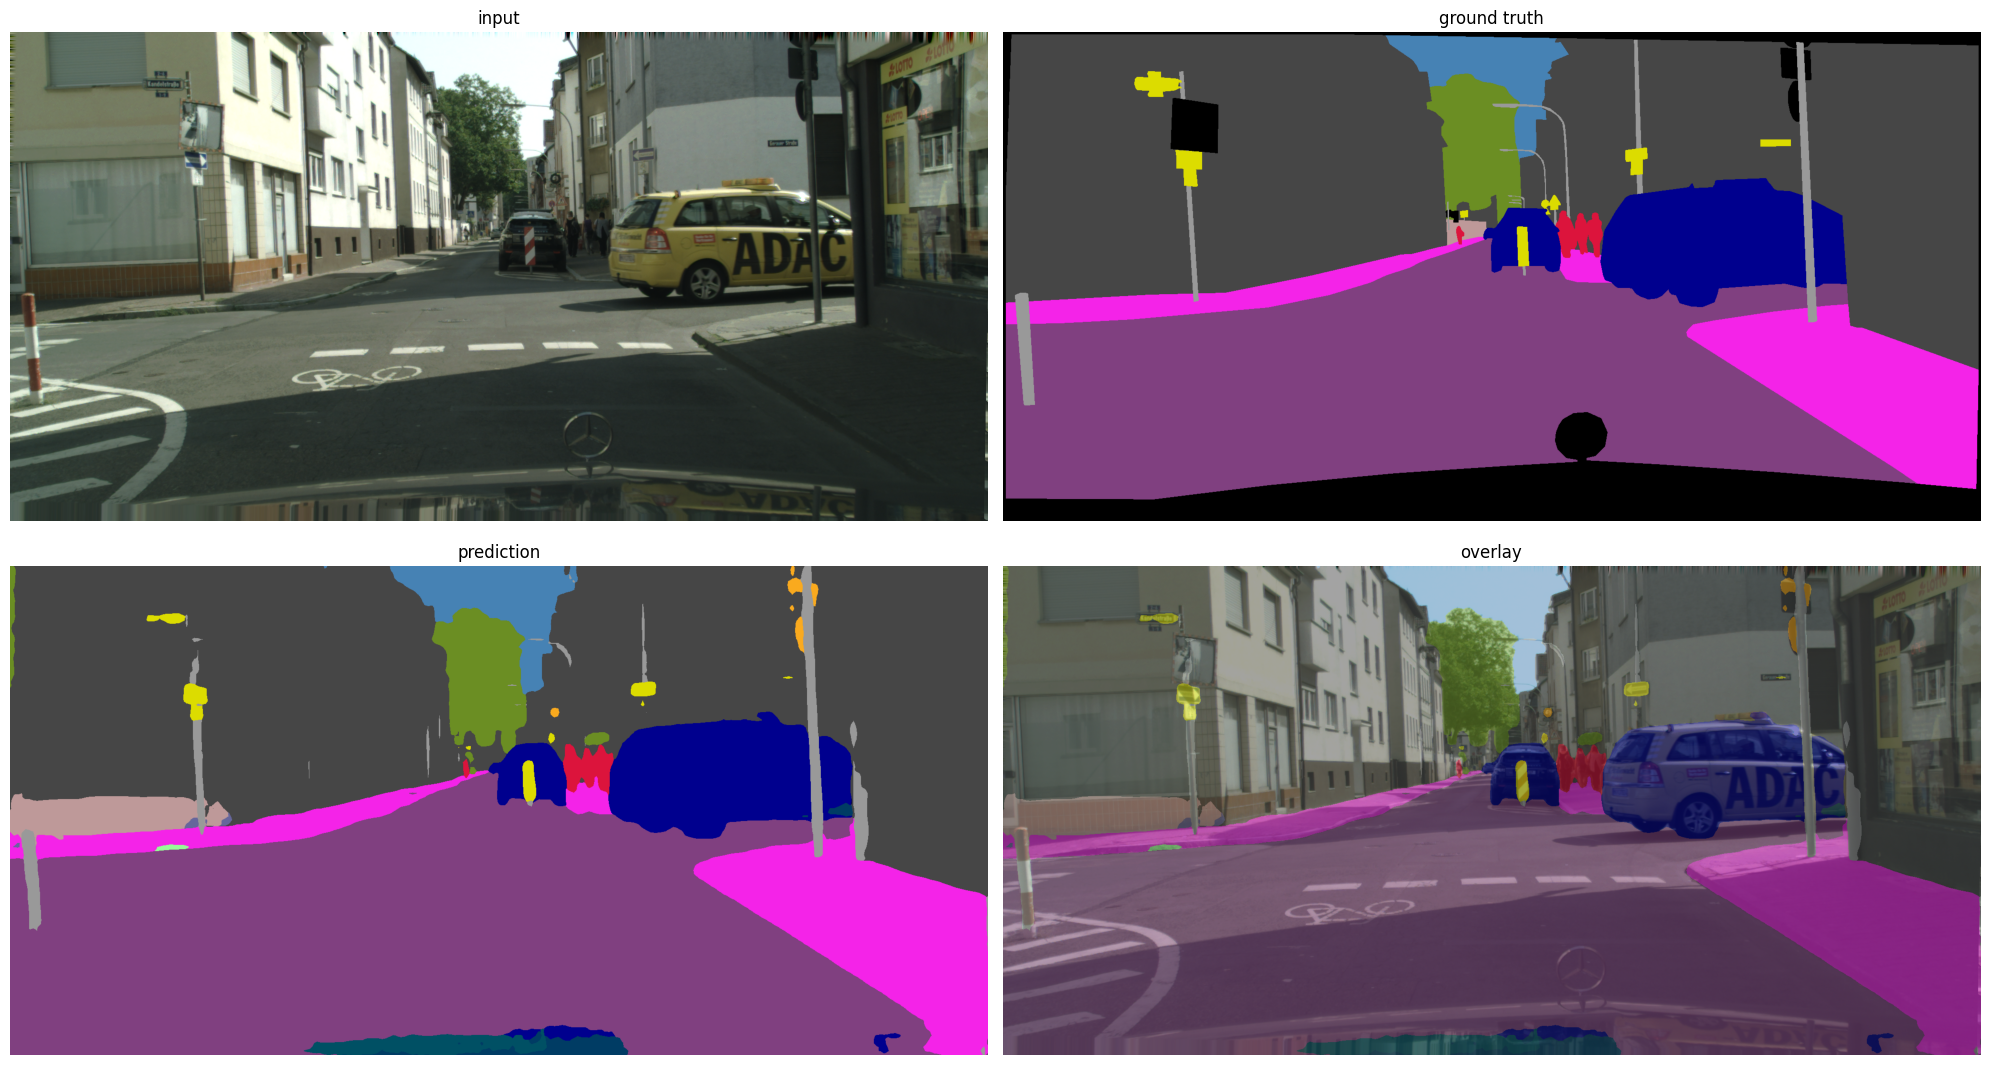

In [16]:
# =============================================================================
# 9. Visualize a prediction on a val image
# =============================================================================
import matplotlib.pyplot as plt

PALETTE = np.array([
 (128,64,128),(244,35,232),(70,70,70),(102,102,156),(190,153,153),(153,153,153),
 (250,170,30),(220,220,0),(107,142,35),(152,251,152),(70,130,180),(220,20,60),
 (255,0,0),(0,0,142),(0,0,70),(0,60,100),(0,80,100),(0,0,230),(119,11,32)], dtype=np.uint8)

# build a lightweight inference model (augment=False -> single output) and load weights
infer = build_pidnet(MODEL_SIZE, NUM_CLASSES, augment=False).to(device).eval()
sd = torch.load(os.path.join(RUN_DIR, "best.pt"), map_location=device)
sd = {k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")}
print("loaded into infer model:", infer.load_state_dict(sd, strict=False))

# pick a val image, preprocess exactly like the loader, run, upsample, colorize
ip, lp = val_pairs[0]
bgr = cv2.imread(ip, cv2.IMREAD_COLOR)
x = ((bgr[:, :, ::-1].astype(np.float32) / 255.0 - MEAN) / STD).transpose(2, 0, 1)[None]
with torch.no_grad():
    out = infer(torch.from_numpy(x).float().to(device))
    out = out[0] if isinstance(out, (list, tuple)) else out
    out = F.interpolate(out, size=bgr.shape[:2], mode='bilinear', align_corners=LOSSCFG.ALIGN_CORNERS)
    pred = out.argmax(1)[0].cpu().numpy()
seg = PALETTE[pred]

# ground truth for reference
gt = cv2.imread(lp, cv2.IMREAD_GRAYSCALE)
gt = val_ds.convert_label(gt)
gt_rgb = np.zeros((*gt.shape, 3), np.uint8)
gt_rgb[gt != 255] = PALETTE[gt[gt != 255]]

fig, ax = plt.subplots(2, 2, figsize=(20, 11))
ax[0,0].imshow(bgr[:, :, ::-1]); ax[0,0].set_title("input")
ax[0,1].imshow(gt_rgb);          ax[0,1].set_title("ground truth")
ax[1,0].imshow(seg);             ax[1,0].set_title("prediction")
ax[1,1].imshow(bgr[:, :, ::-1]); ax[1,1].imshow(seg, alpha=0.5); ax[1,1].set_title("overlay")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

In [10]:
import torch
p = "/home/dpraju90/scratch/PIDNet_S_ImageNet.pth.tar"
ck = torch.load(p, map_location="cpu", weights_only=False)
sd = ck["state_dict"] if isinstance(ck, dict) and "state_dict" in ck else ck
print("total tensors:", len(sd))
print("has seghead:", any("seghead" in k for k in sd))   # expect False
print("has classifier fc:", any(k.startswith(("fc.","classifier","head")) for k in sd))  # expect True
print("sample keys:", list(sd.keys())[:6])

total tensors: 322
has seghead: False
has classifier fc: False
sample keys: ['conv1.0.weight', 'conv1.0.bias', 'conv1.1.weight', 'conv1.1.bias', 'conv1.1.running_mean', 'conv1.1.running_var']


In [11]:
IMAGENET_PRETRAINED = "/home/dpraju90/scratch/PIDNet_S_ImageNet.pth.tar"
if IMAGENET_PRETRAINED:
    assert os.path.isfile(IMAGENET_PRETRAINED), f"missing: {IMAGENET_PRETRAINED}"
    ck = torch.load(IMAGENET_PRETRAINED, map_location="cpu", weights_only=False)
    state = ck["state_dict"] if "state_dict" in ck else ck
    md = net.state_dict()
    loaded = {k: v for k, v in state.items() if k in md and v.shape == md[k].shape}
    md.update(loaded); net.load_state_dict(md, strict=False)
    print(f"ImageNet init: loaded {len(loaded)}/{len(md)} tensors")
else:
    print("from scratch (no ImageNet init)")

ImageNet init: loaded 302/479 tensors


In [17]:
# ===== Experiment A: quantitative results =====
import os, cv2, numpy as np, torch, torch.nn.functional as F
from tqdm.auto import tqdm

RESULTS = os.path.join(RUN_DIR, "results_A"); os.makedirs(RESULTS, exist_ok=True)
CLASS_NAMES = ["road","sidewalk","building","wall","fence","pole","traffic light",
               "traffic sign","vegetation","terrain","sky","person","rider","car",
               "truck","bus","train","motorcycle","bicycle"]

# build a clean inference model (augment=False -> single output) from best.pt
infer = build_pidnet(MODEL_SIZE, NUM_CLASSES, augment=False).to(device).eval()
sd = torch.load(os.path.join(RUN_DIR, "best.pt"), map_location=device, weights_only=False)
sd = {k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")}
print("loaded:", infer.load_state_dict(sd, strict=False))

val_ds_A = CityscapesDataset(val_pairs, multi_scale=False, flip=False, ignore_label=IGNORE_LABEL)
val_ld_A = torch.utils.data.DataLoader(val_ds_A, batch_size=1, shuffle=False,
                                       num_workers=WORKERS, pin_memory=False)

def boundary_f1(pred_lbl, gt_lbl, ignore=255, tol=2):
    def bmap(x):
        e = cv2.Canny(x.astype(np.uint8),0.1,0.2); e[x==ignore]=0; return e>0
    gb,pb = bmap(gt_lbl), bmap(pred_lbl)
    if gb.sum()==0 and pb.sum()==0: return 1.0
    if gb.sum()==0 or pb.sum()==0:  return 0.0
    gd = cv2.distanceTransform((~gb).astype(np.uint8),cv2.DIST_L2,3)
    pd = cv2.distanceTransform((~pb).astype(np.uint8),cv2.DIST_L2,3)
    prec=(pd[pb]<=tol).mean(); rec=(gd[gb]<=tol).mean()
    return 0.0 if prec+rec==0 else 2*prec*rec/(prec+rec)

cm = np.zeros((NUM_CLASSES,NUM_CLASSES)); bf=[]
with torch.no_grad():
    for image,label,_ in tqdm(val_ld_A, desc="eval A"):
        image=image.to(device); label=label.long().to(device)
        out = infer(image); out = out[0] if isinstance(out,(list,tuple)) else out
        out = F.interpolate(out, size=label.shape[-2:], mode='bilinear', align_corners=True)
        cm += get_confusion_matrix(label, out, label.size(), NUM_CLASSES, IGNORE_LABEL)
        bf.append(boundary_f1(out.argmax(1)[0].cpu().numpy(), label[0].cpu().numpy(), IGNORE_LABEL))

pos,res,tp = cm.sum(1),cm.sum(0),np.diag(cm)
iou = tp/np.maximum(1.0,pos+res-tp)
mIoU, pix_acc, bf1 = iou.mean(), tp.sum()/cm.sum(), float(np.mean(bf))
np.savez(os.path.join(RESULTS,"metrics.npz"), cm=cm, iou=iou, mIoU=mIoU, pix_acc=pix_acc, bf1=bf1)
with open(os.path.join(RESULTS,"metrics.csv"),"w") as f:
    f.write("class,IoU\n")
    for n,v in zip(CLASS_NAMES,iou): f.write(f"{n},{v:.4f}\n")
    f.write(f"mIoU,{mIoU:.4f}\npixel_acc,{pix_acc:.4f}\nboundary_f1,{bf1:.4f}\n")

print(f"\nmIoU {mIoU:.4f} | pixel-acc {pix_acc:.4f} | Boundary-F1 {bf1:.4f}\n")
for n,v in sorted(zip(CLASS_NAMES,iou), key=lambda t:-t[1]):
    print(f"  {n:14s} {v:.4f}")

loaded: _IncompatibleKeys(missing_keys=[], unexpected_keys=['seghead_p.bn1.weight', 'seghead_p.bn1.bias', 'seghead_p.bn1.running_mean', 'seghead_p.bn1.running_var', 'seghead_p.bn1.num_batches_tracked', 'seghead_p.conv1.weight', 'seghead_p.bn2.weight', 'seghead_p.bn2.bias', 'seghead_p.bn2.running_mean', 'seghead_p.bn2.running_var', 'seghead_p.bn2.num_batches_tracked', 'seghead_p.conv2.weight', 'seghead_p.conv2.bias', 'seghead_d.bn1.weight', 'seghead_d.bn1.bias', 'seghead_d.bn1.running_mean', 'seghead_d.bn1.running_var', 'seghead_d.bn1.num_batches_tracked', 'seghead_d.conv1.weight', 'seghead_d.bn2.weight', 'seghead_d.bn2.bias', 'seghead_d.bn2.running_mean', 'seghead_d.bn2.running_var', 'seghead_d.bn2.num_batches_tracked', 'seghead_d.conv2.weight', 'seghead_d.conv2.bias'])


/home/dpraju90/envs/jupyter-lab/lib/python3.11/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


eval A:   0%|          | 0/500 [00:00<?, ?it/s]


mIoU 0.6624 | pixel-acc 0.9424 | Boundary-F1 1.0000

  road           0.9661
  sky            0.9273
  car            0.9218
  vegetation     0.9077
  building       0.8982
  sidewalk       0.7678
  person         0.7338
  traffic sign   0.7058
  bicycle        0.6928
  bus            0.6616
  traffic light  0.6055
  terrain        0.5879
  pole           0.5392
  train          0.5210
  rider          0.5102
  truck          0.4853
  fence          0.4831
  wall           0.3686
  motorcycle     0.3021


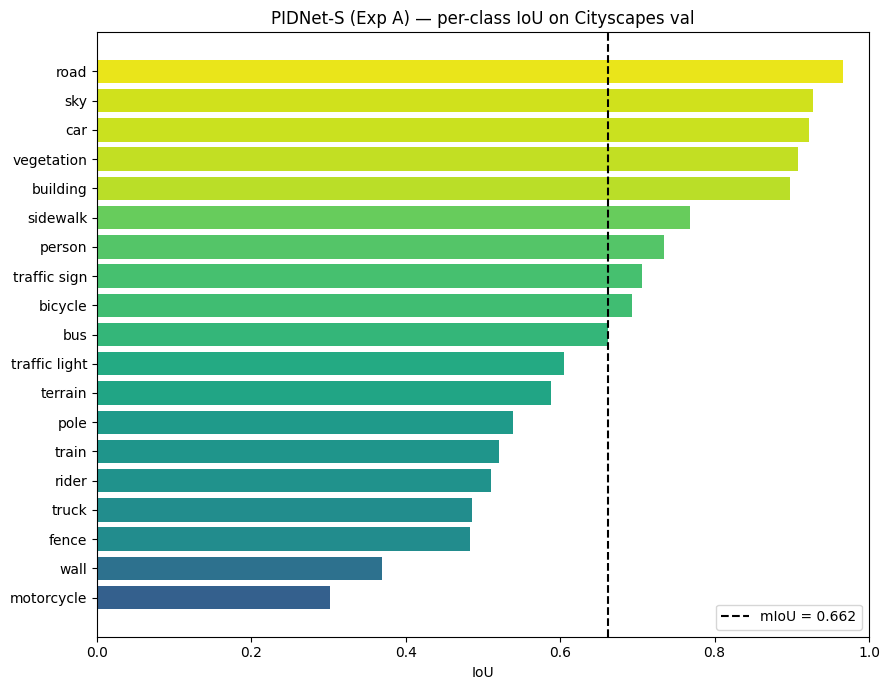

In [18]:
import matplotlib.pyplot as plt
d = np.load(os.path.join(RESULTS,"metrics.npz")); iou=d["iou"]; mIoU=float(d["mIoU"])
order = np.argsort(iou)
fig,ax = plt.subplots(figsize=(9,7))
ax.barh([CLASS_NAMES[i] for i in order],[iou[i] for i in order],color=plt.cm.viridis(iou[order]))
ax.axvline(mIoU, ls="--", color="k", label=f"mIoU = {mIoU:.3f}")
ax.set_xlabel("IoU"); ax.set_xlim(0,1); ax.legend(); ax.set_title("PIDNet-S (Exp A) — per-class IoU on Cityscapes val")
plt.tight_layout(); plt.savefig(os.path.join(RESULTS,"per_class_iou.png"), dpi=150); plt.show()

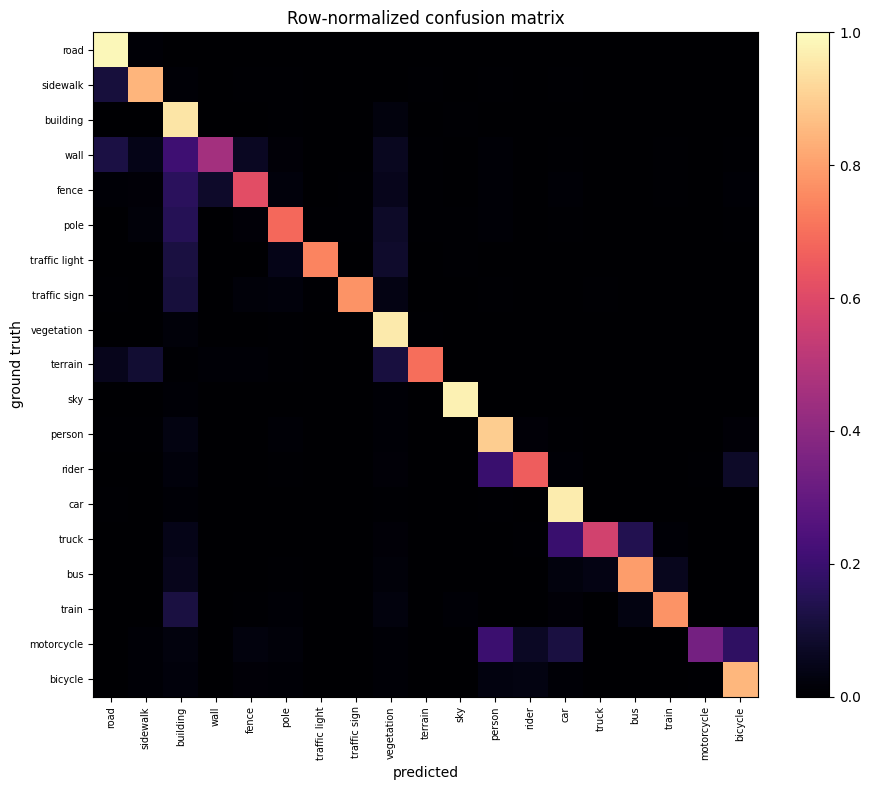

In [19]:
d = np.load(os.path.join(RESULTS,"metrics.npz")); cm=d["cm"]
cmn = cm/np.maximum(1,cm.sum(1,keepdims=True))
fig,ax = plt.subplots(figsize=(9,8))
im = ax.imshow(cmn, cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(19)); ax.set_yticks(range(19))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=7); ax.set_yticklabels(CLASS_NAMES, fontsize=7)
ax.set_xlabel("predicted"); ax.set_ylabel("ground truth")
ax.set_title("Row-normalized confusion matrix")
plt.colorbar(im, fraction=0.046); plt.tight_layout()
plt.savefig(os.path.join(RESULTS,"confusion.png"), dpi=150); plt.show()

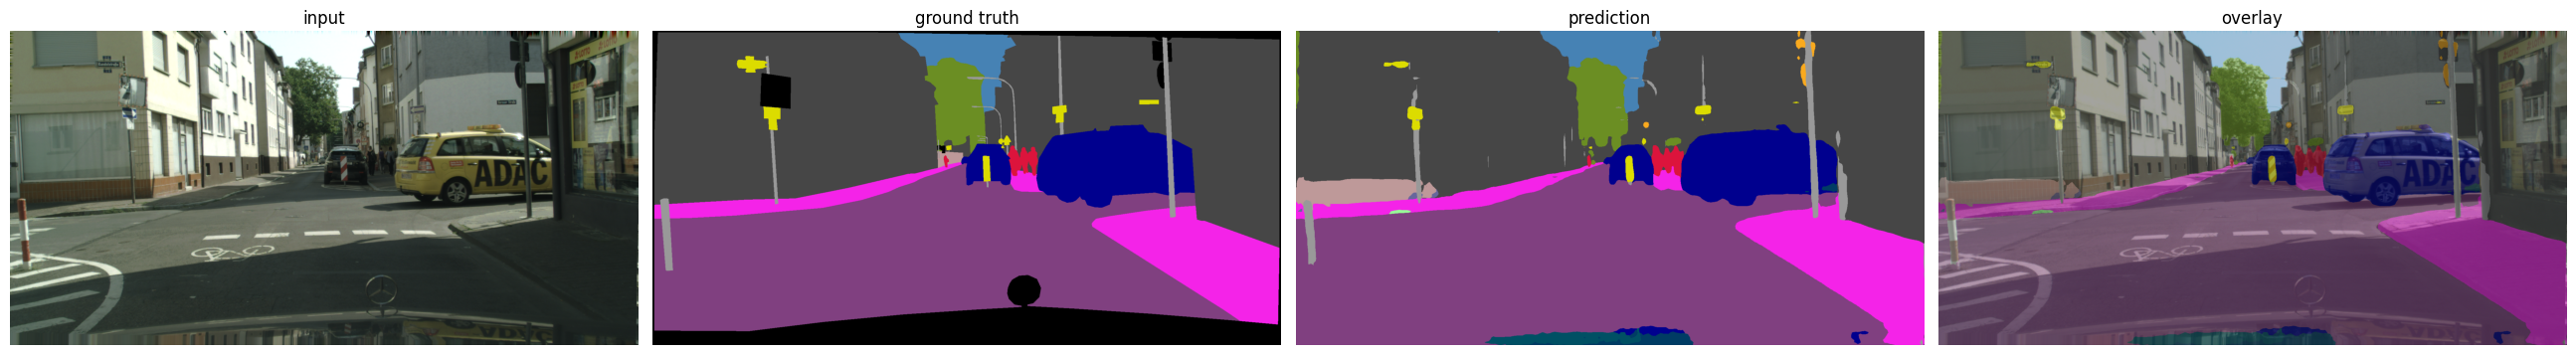

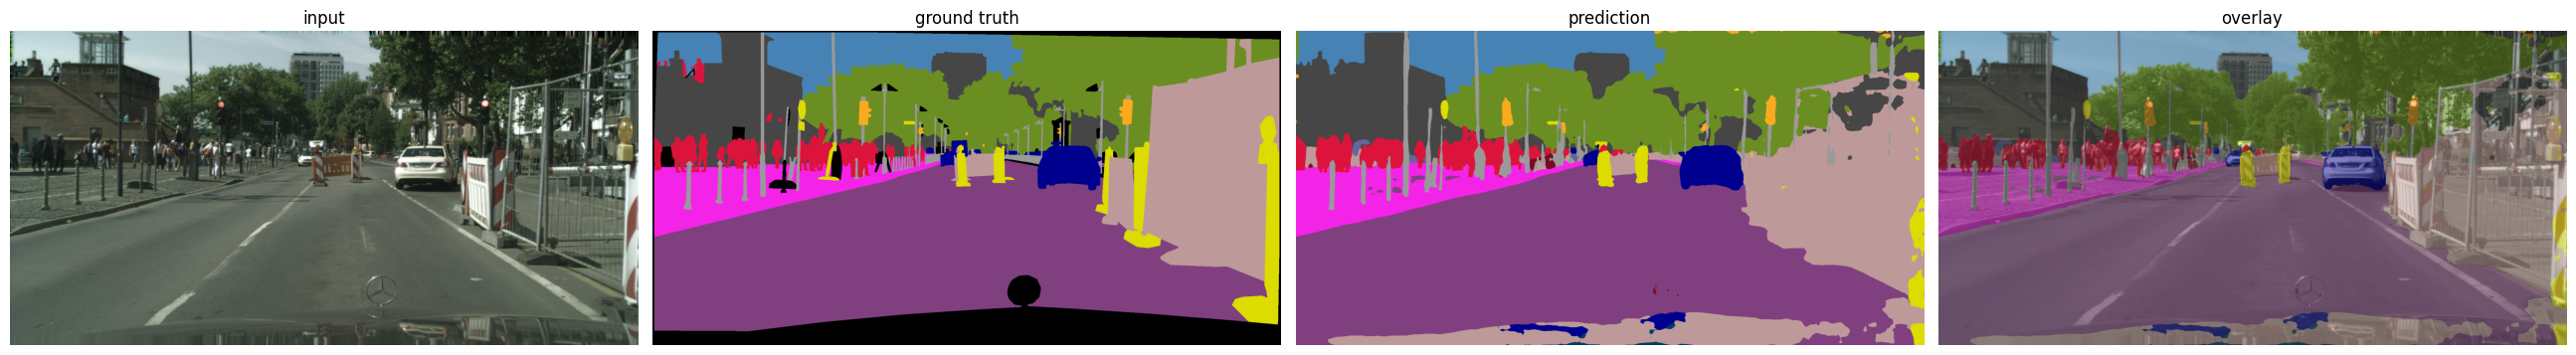

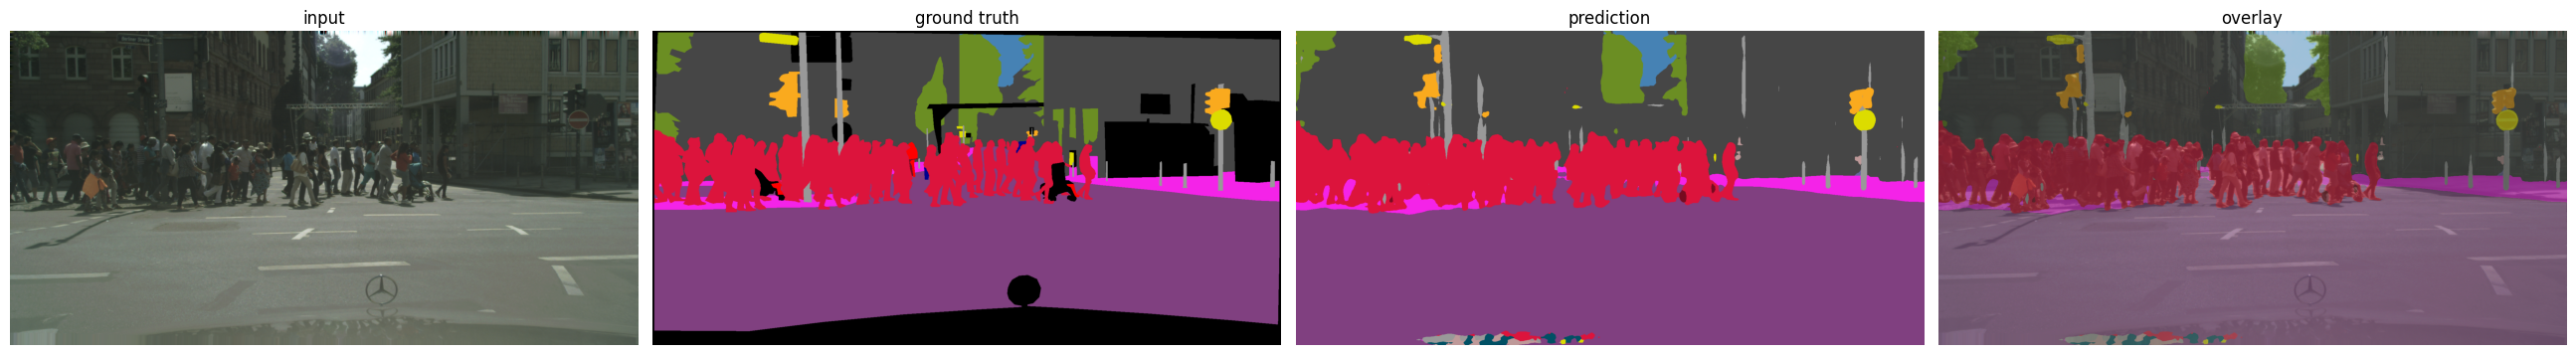

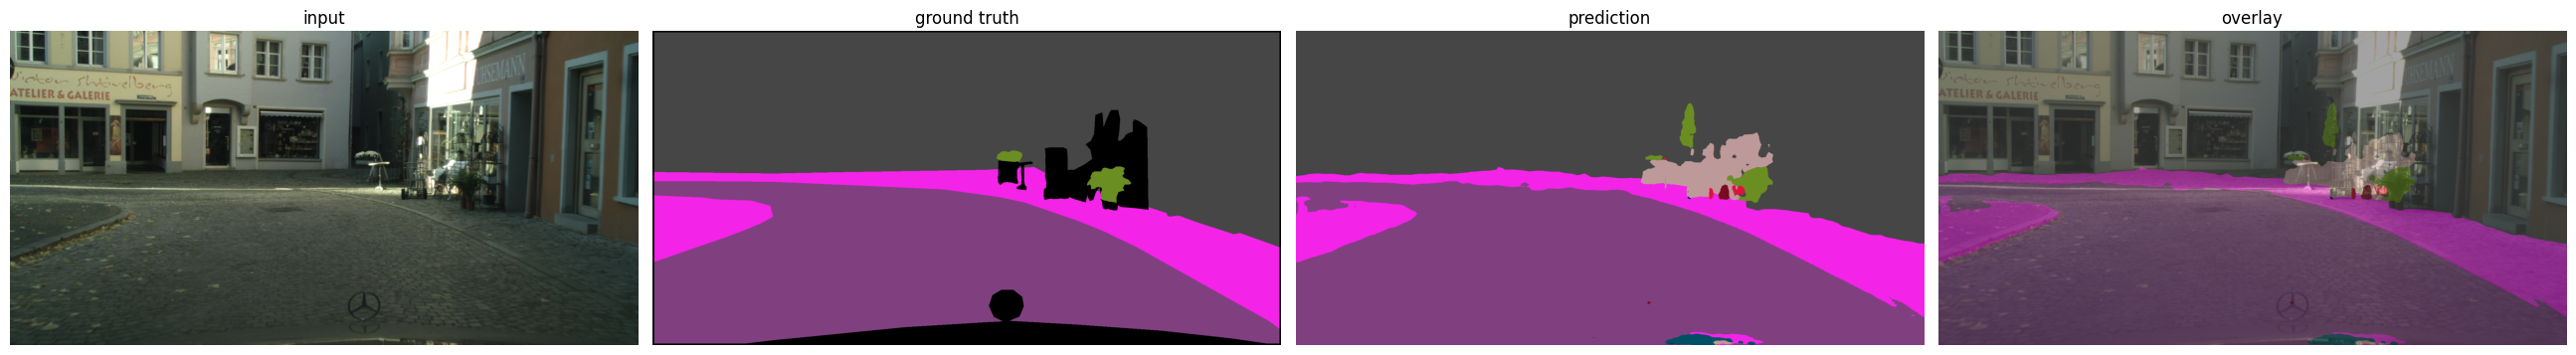

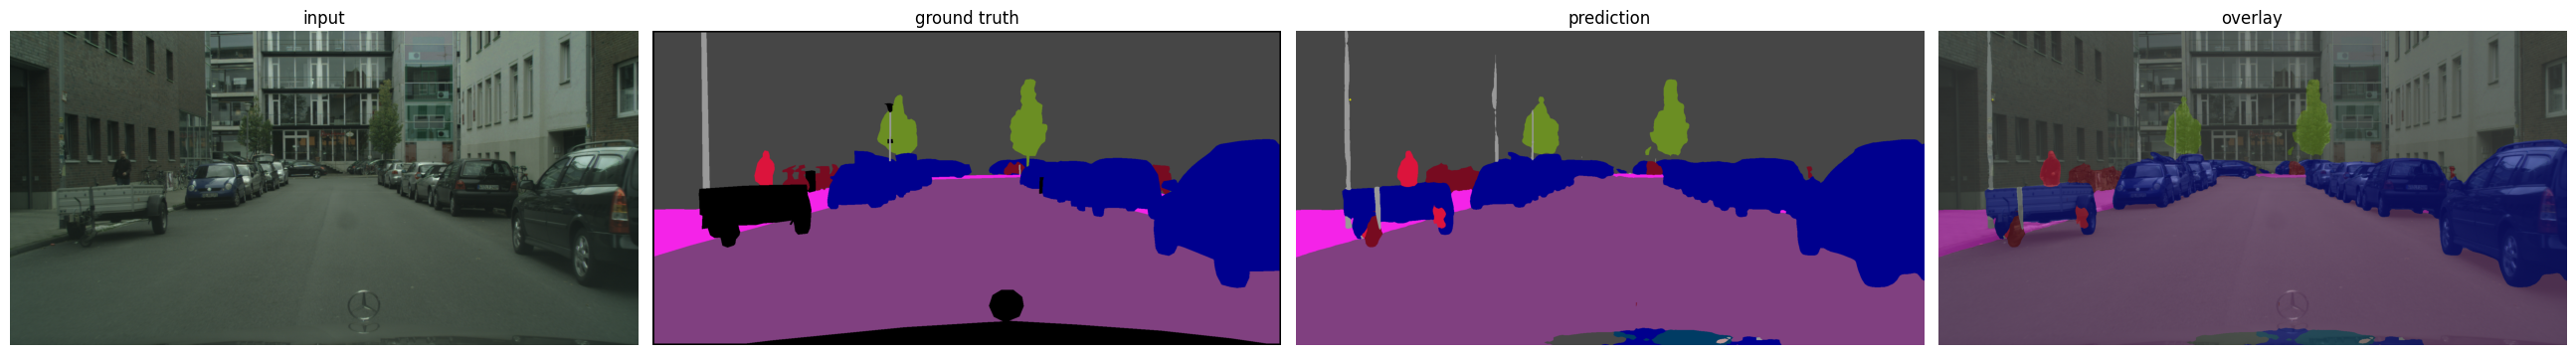

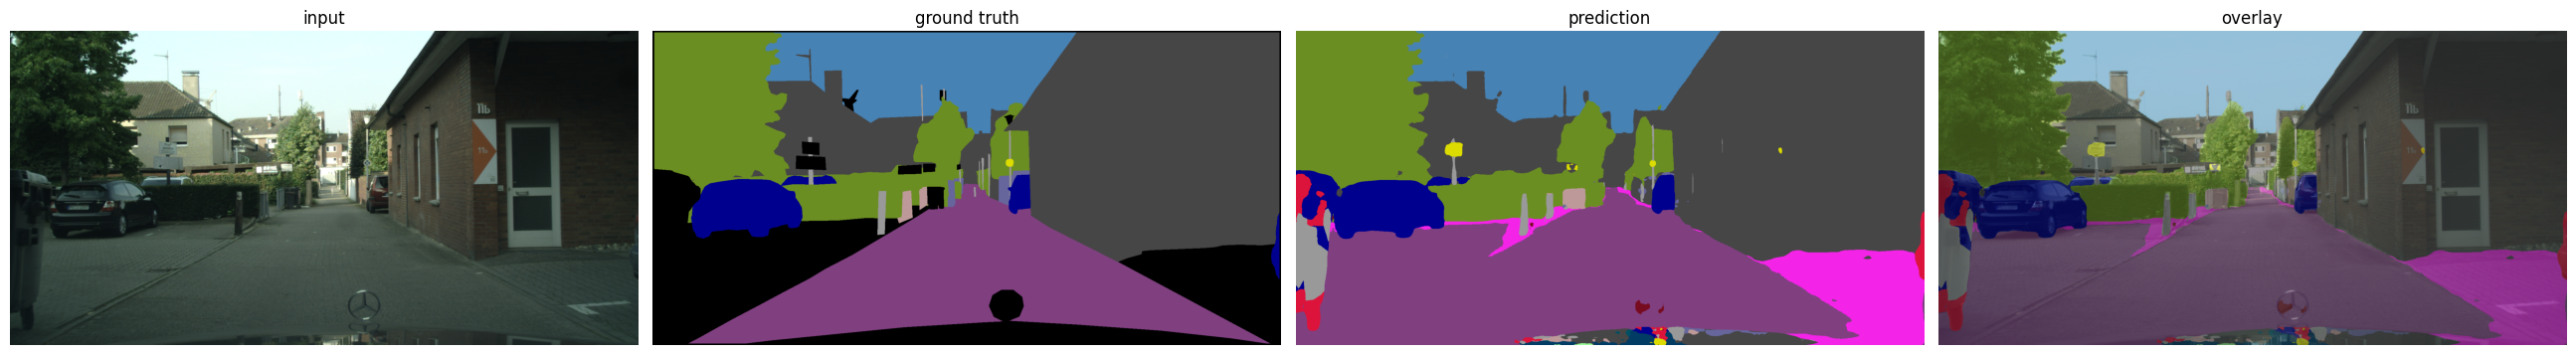

saved qualitative panels to /home/dpraju90/scratch/pidnet_runs/pidnet_s_cityscapes/results_A


In [20]:
PALETTE = np.array([(128,64,128),(244,35,232),(70,70,70),(102,102,156),(190,153,153),
 (153,153,153),(250,170,30),(220,220,0),(107,142,35),(152,251,152),(70,130,180),
 (220,20,60),(255,0,0),(0,0,142),(0,0,70),(0,60,100),(0,80,100),(0,0,230),(119,11,32)],np.uint8)
def colorize(lbl):
    rgb=np.zeros((*lbl.shape,3),np.uint8); m=lbl!=255; rgb[m]=PALETTE[lbl[m]]; return rgb

N = 6   # how many val images to render
idxs = np.linspace(0, len(val_pairs)-1, N).astype(int)
for j,idx in enumerate(idxs):
    ip,lp = val_pairs[idx]
    bgr = cv2.imread(ip, cv2.IMREAD_COLOR)
    x = ((bgr[:,:,::-1].astype(np.float32)/255.0 - MEAN)/STD).transpose(2,0,1)[None]
    with torch.no_grad():
        out = infer(torch.from_numpy(x).float().to(device))
        out = out[0] if isinstance(out,(list,tuple)) else out
        out = F.interpolate(out, size=bgr.shape[:2], mode='bilinear', align_corners=True)
        pred = out.argmax(1)[0].cpu().numpy()
    gt = val_ds_A.convert_label(cv2.imread(lp, cv2.IMREAD_GRAYSCALE))
    seg, gtc = colorize(pred), colorize(gt)
    fig,ax = plt.subplots(1,4, figsize=(26,5))
    ax[0].imshow(bgr[:,:,::-1]); ax[0].set_title("input")
    ax[1].imshow(gtc);           ax[1].set_title("ground truth")
    ax[2].imshow(seg);           ax[2].set_title("prediction")
    ax[3].imshow(bgr[:,:,::-1]); ax[3].imshow(seg, alpha=0.5); ax[3].set_title("overlay")
    for a in ax: a.axis("off")
    plt.tight_layout(); plt.savefig(os.path.join(RESULTS,f"qualitative_{j}.png"), dpi=130); plt.show()
print("saved qualitative panels to", RESULTS)